**Data Collecting & Integration** 

1. Data Jumlah Penumpang Transportasi Umum Daerah Khusus Ibukota Jakarta Tahun 2023-2024 : Dataset Satu Data Jakarta
2. Data Cuaca Jakarta 2023-2024 : Diambil dari Web Historical Weather API (open-mateo.com) dengan koordinat lokasi -6,2 latitude dan 106,8 longitude 

In [785]:
# import library yang diperlukan
import numpy as np
import pandas as pd

In [786]:
# baca data penumpang 2023
df_penumpang23 = pd.read_csv("data_penumpang_2023.csv")
df_penumpang23

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
0,202301,2023-01-01,bus sekolah,0
1,202301,2023-01-02,bus sekolah,33547
2,202301,2023-01-03,bus sekolah,38123
3,202301,2023-01-04,bus sekolah,40740
4,202301,2023-01-05,bus sekolah,42587
...,...,...,...,...
2550,202312,2023-12-27,transjakarta,1012112
2551,202312,2023-12-28,transjakarta,1010097
2552,202312,2023-12-29,transjakarta,974703
2553,202312,2023-12-30,transjakarta,748326


In [787]:
# baca data penumpang 2024
df_penumpang24 = pd.read_csv("data_penumpang_2024.csv")
df_penumpang24

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
0,202402,2024-02-25,kapal,4535
1,202402,2024-02-26,kapal,1830
2,202402,2024-02-27,kapal,1673
3,202402,2024-02-28,kapal,1479
4,202402,2024-02-29,kapal,1477
...,...,...,...,...
4258,202508,2025-08-27,kapal,1169
4259,202508,2025-08-28,kapal,1647
4260,202508,2025-08-29,kapal,1230
4261,202508,2025-08-30,kapal,5270


In [788]:
df_penumpang23.info()
df_penumpang24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2555 entries, 0 to 2554
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   periode_data               2555 non-null   int64 
 1   tanggal                    2555 non-null   object
 2   jenis_moda                 2555 non-null   object
 3   jumlah_penumpang_per_hari  2555 non-null   object
dtypes: int64(1), object(3)
memory usage: 80.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4263 entries, 0 to 4262
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   periode_data               4263 non-null   int64 
 1   tanggal                    4263 non-null   object
 2   jenis_moda                 4263 non-null   object
 3   jumlah_penumpang_per_hari  4263 non-null   object
dtypes: int64(1), object(3)
memory usage: 133.3+ KB


In [789]:
df_penumpang23.columns

Index(['periode_data', 'tanggal', 'jenis_moda', 'jumlah_penumpang_per_hari'], dtype='object')

In [790]:
df_penumpang24.columns

Index(['periode_data', 'tanggal', 'jenis_moda', 'jumlah_penumpang_per_hari'], dtype='object')

In [791]:
df_penumpangabungan = pd.concat([df_penumpang23, df_penumpang24], ignore_index=True)
df_penumpangabungan

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
0,202301,2023-01-01,bus sekolah,0
1,202301,2023-01-02,bus sekolah,33547
2,202301,2023-01-03,bus sekolah,38123
3,202301,2023-01-04,bus sekolah,40740
4,202301,2023-01-05,bus sekolah,42587
...,...,...,...,...
6813,202508,2025-08-27,kapal,1169
6814,202508,2025-08-28,kapal,1647
6815,202508,2025-08-29,kapal,1230
6816,202508,2025-08-30,kapal,5270


In [792]:
df_penumpangabungan.info()
df_penumpangabungan.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   periode_data               6818 non-null   int64 
 1   tanggal                    6818 non-null   object
 2   jenis_moda                 6818 non-null   object
 3   jumlah_penumpang_per_hari  6818 non-null   object
dtypes: int64(1), object(3)
memory usage: 213.2+ KB


(6818, 4)

**Pre-Processing: Data Penumpang**

In [793]:
# Cek semua kolom pada data penumpangabungan
df_penumpangabungan.columns

Index(['periode_data', 'tanggal', 'jenis_moda', 'jumlah_penumpang_per_hari'], dtype='object')

In [794]:
# Ambil data penumpang tahun 2023-2024 saja
df_penumpangabungan['tanggal'] = pd.to_datetime(df_penumpangabungan['tanggal'], errors = 'coerce')
df_penumpang = df_penumpangabungan[df_penumpangabungan['tanggal'].dt.year.isin([2023,2024])]
df_penumpang

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
0,202301,2023-01-01,bus sekolah,0
1,202301,2023-01-02,bus sekolah,33547
2,202301,2023-01-03,bus sekolah,38123
3,202301,2023-01-04,bus sekolah,40740
4,202301,2023-01-05,bus sekolah,42587
...,...,...,...,...
5304,202412,2024-12-31,KCI Commuter Bandara,3004
5305,202412,2024-12-01,kapal,4282
5306,202412,2024-12-02,kapal,1234
5307,202412,2024-12-03,kapal,1135


In [795]:
# cek tipe data tangal
df_penumpang.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4201 entries, 0 to 5308
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   periode_data               4201 non-null   int64         
 1   tanggal                    4201 non-null   datetime64[ns]
 2   jenis_moda                 4201 non-null   object        
 3   jumlah_penumpang_per_hari  4201 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 164.1+ KB


In [796]:
# cek apakah ada data yang NaN atau NaT
df_penumpang.isna().sum()

periode_data                 0
tanggal                      0
jenis_moda                   0
jumlah_penumpang_per_hari    0
dtype: int64

In [797]:
df_penumpang['jenis_moda'].unique()

array(['bus sekolah', 'kapal', 'krl', 'lrt', 'mrt', 'railink',
       'transjakarta', '  lrt  ', '  mrt  ', ' krl ',
       ' KCI Commuter Bandara ', 'KCI Commuter Bandara', ' bus sekolah ',
       ' kapal ', ' transjakarta '], dtype=object)

In [ ]:
# Proses pre-processing pada kolom jenis_moda
df_penumpang.loc[:,'jenis_moda'] = (df_penumpang['jenis_moda'].str.strip().str.lower())
df_penumpang['jenis_moda'].unique()

array(['bus sekolah', 'kapal', 'krl', 'lrt', 'mrt', 'railink',
       'transjakarta', 'kci commuter bandara'], dtype=object)

In [799]:
# Cek apakah ada data yang NaN atau NaT
df_penumpang['jenis_moda'].isna().sum()

0

Ambil data berdasarkan jenis moda

In [800]:
df_penumpang['jenis_moda'].unique()

array(['bus sekolah', 'kapal', 'krl', 'lrt', 'mrt', 'railink',
       'transjakarta', 'kci commuter bandara'], dtype=object)

1. Ambil data bus

In [801]:
df_bus = df_penumpang[df_penumpang['jenis_moda'] == 'bus sekolah'].reset_index(drop=True)
df_bus.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
604,202412,2024-12-27,bus sekolah,0
605,202412,2024-12-28,bus sekolah,0
606,202412,2024-12-29,bus sekolah,0
607,202412,2024-12-30,bus sekolah,0
608,202412,2024-12-31,bus sekolah,0


2. Ambil data kapal

In [802]:
df_kapal = df_penumpang[df_penumpang['jenis_moda'] == 'kapal'].reset_index(drop=True)
df_kapal.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
604,202411,2024-11-30,kapal,4499
605,202412,2024-12-01,kapal,4282
606,202412,2024-12-02,kapal,1234
607,202412,2024-12-03,kapal,1135
608,202412,2024-12-04,kapal,875


3. Ambil data KRL

In [803]:
df_krl = df_penumpang[df_penumpang['jenis_moda'] == 'krl'].reset_index(drop=True)
df_krl.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
573,202412,2024-12-27,krl,932855
574,202412,2024-12-28,krl,839635
575,202412,2024-12-29,krl,794896
576,202412,2024-12-30,krl,1017880
577,202412,2024-12-31,krl,390448


4. Ambil data LRT

In [804]:
df_lrt = df_penumpang[df_penumpang['jenis_moda'] == 'lrt'].reset_index(drop=True)
df_lrt.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
604,202412,2024-12-27,lrt,3317
605,202412,2024-12-28,lrt,3079
606,202412,2024-12-29,lrt,2778
607,202412,2024-12-30,lrt,3406
608,202412,2024-12-31,lrt,6367


5. Ambil data MRT

In [805]:
df_mrt = df_penumpang[df_penumpang['jenis_moda'] == 'mrt'].reset_index(drop=True)
df_mrt.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
604,202412,2024-12-27,mrt,117164
605,202412,2024-12-28,mrt,82421
606,202412,2024-12-29,mrt,86507
607,202412,2024-12-30,mrt,122745
608,202412,2024-12-31,mrt,154609


6. Ambil data railink

In [806]:
df_railink = df_penumpang[df_penumpang['jenis_moda'] == 'railink'].reset_index(drop=True)
df_railink.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
54,202302,2023-02-24,railink,"4,768"
55,202302,2023-02-25,railink,"3,461"
56,202302,2023-02-26,railink,"3,596"
57,202302,2023-02-27,railink,"4,563"
58,202302,2023-02-28,railink,"4,390"


7. Ambil data transjakarta

In [807]:
df_transjakarta = df_penumpang[df_penumpang['jenis_moda'] == 'transjakarta'].reset_index(drop=True)
df_transjakarta.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
604,202412,2024-12-27,transjakarta,1055174
605,202412,2024-12-28,transjakarta,852428
606,202412,2024-12-29,transjakarta,799846
607,202412,2024-12-30,transjakarta,1071256
608,202412,2024-12-31,transjakarta,1056165


8. Ambil data KCI 

In [808]:
df_kci = df_penumpang[df_penumpang['jenis_moda'] == 'kci commuter bandara'].reset_index(drop=True)
df_kci.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
514,202412,2024-12-27,kci commuter bandara,5373
515,202412,2024-12-28,kci commuter bandara,4618
516,202412,2024-12-29,kci commuter bandara,5156
517,202412,2024-12-30,kci commuter bandara,5423
518,202412,2024-12-31,kci commuter bandara,3004


Ambil data semua moda transportasi

In [809]:
df_moda = df_penumpang[df_penumpang['jenis_moda']
              .isin(['bus sekolah', 'kapal', 'krl', 'lrt', 'mrt', 'railink',
              'transjakarta', 'kci commuter bandara'])]
df_moda

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari
0,202301,2023-01-01,bus sekolah,0
1,202301,2023-01-02,bus sekolah,33547
2,202301,2023-01-03,bus sekolah,38123
3,202301,2023-01-04,bus sekolah,40740
4,202301,2023-01-05,bus sekolah,42587
...,...,...,...,...
5304,202412,2024-12-31,kci commuter bandara,3004
5305,202412,2024-12-01,kapal,4282
5306,202412,2024-12-02,kapal,1234
5307,202412,2024-12-03,kapal,1135


**Integrasi Data ke-2: Data Cuaca**

In [810]:
# Baca file data cuaca Jakarta 2023
cuaca23 = pd.read_csv("data_cuaca_jakarta_2023.csv", header=None)
cuaca23

,0,1,2,3,4,5
0,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
1,-6.221441,106.78094,15.0,25200,Asia/Bangkok,GMT+7
2,time,relative_humidity_2m (%),rain (mm),temperature_2m (°C),NaN,NaN
3,2023-01-01T00:00,96,0.20,22.5,NaN,NaN
4,2023-01-01T01:00,96,0.20,22.4,NaN,NaN
...,...,...,...,...,...,...
9124,2023-12-27,27.0,NaN,NaN,NaN,NaN
9125,2023-12-28,27.4,NaN,NaN,NaN,NaN
9126,2023-12-29,27.5,NaN,NaN,NaN,NaN
9127,2023-12-30,27.0,NaN,NaN,NaN,NaN


In [811]:
cuaca23 = pd.read_csv("data_cuaca_jakarta_2023.csv", header=2)
cuaca23 = cuaca23.iloc[0:8760] # Ambil data dari 1 Januari hingga 31 Desember 2023
cuaca23

,time,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,2023-01-01T00:00,96,0.2,22.5
1,2023-01-01T01:00,96,0.2,22.4
2,2023-01-01T02:00,98,0.7,22.0
3,2023-01-01T03:00,99,6.7,21.7
4,2023-01-01T04:00,97,1.4,21.9
...,...,...,...,...
8755,2023-12-31T19:00,94,0.0,24.5
8756,2023-12-31T20:00,92,0.0,25.7
8757,2023-12-31T21:00,94,0.0,25.3
8758,2023-12-31T22:00,96,0.0,24.9


In [812]:
# Baca file data cuaca Jakarta 2024
cuaca24 = pd.read_csv("data_cuaca_jakarta_2024.csv", header=None)
cuaca24

,0,1,2,3,4,5
0,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
1,-6.221441,106.78094,15.0,25200,Asia/Bangkok,GMT+7
2,time,relative_humidity_2m (%),rain (mm),temperature_2m (°C),NaN,NaN
3,2024-01-01T00:00,95,0.00,25.2,NaN,NaN
4,2024-01-01T01:00,98,0.00,24.4,NaN,NaN
...,...,...,...,...,...,...
9149,2024-12-27,28.0,NaN,NaN,NaN,NaN
9150,2024-12-28,28.6,NaN,NaN,NaN,NaN
9151,2024-12-29,27.6,NaN,NaN,NaN,NaN
9152,2024-12-30,26.7,NaN,NaN,NaN,NaN


In [813]:
cuaca24 = pd.read_csv("data_cuaca_jakarta_2024.csv", header=2)
cuaca24 = cuaca24.iloc[0:8784] # Ambil data dari 1 Januari hingga 31 Desember 2024
cuaca24

,time,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,2024-01-01T00:00,95,0.0,25.2
1,2024-01-01T01:00,98,0.0,24.4
2,2024-01-01T02:00,99,0.0,24.1
3,2024-01-01T03:00,99,0.0,24.1
4,2024-01-01T04:00,99,0.0,24.1
...,...,...,...,...
8779,2024-12-31T19:00,78,0.0,27.3
8780,2024-12-31T20:00,82,0.1,27.1
8781,2024-12-31T21:00,82,0.0,26.9
8782,2024-12-31T22:00,85,0.0,26.4


In [814]:
# Cek tipe data dari setiap kolom 
cuaca23.info()
cuaca24.info()
cuaca23.columns
cuaca24.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time                      8760 non-null   object 
 1   relative_humidity_2m (%)  8760 non-null   object 
 2   rain (mm)                 8760 non-null   float64
 3   temperature_2m (°C)       8760 non-null   float64
dtypes: float64(2), object(2)
memory usage: 273.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time                      8784 non-null   object 
 1   relative_humidity_2m (%)  8784 non-null   object 
 2   rain (mm)                 8784 non-null   float64
 3   temperature_2m (°C)       8784 non-null   float64
dtypes: float64(2), object(2)
memory usage: 274.6+ KB


Index(['time', 'relative_humidity_2m (%)', 'rain (mm)', 'temperature_2m (°C)'], dtype='object')

In [ ]:
# Gabung data cuaca Jakarta tahun 2023 dan 2024
data_cuaca = pd.concat([cuaca23, cuaca24], ignore_index=True)
data_cuaca

,time,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,2023-01-01T00:00,96,0.2,22.5
1,2023-01-01T01:00,96,0.2,22.4
2,2023-01-01T02:00,98,0.7,22.0
3,2023-01-01T03:00,99,6.7,21.7
4,2023-01-01T04:00,97,1.4,21.9
...,...,...,...,...
17539,2024-12-31T19:00,78,0.0,27.3
17540,2024-12-31T20:00,82,0.1,27.1
17541,2024-12-31T21:00,82,0.0,26.9
17542,2024-12-31T22:00,85,0.0,26.4


**Pre-Processing: Data Cuaca**

In [816]:
# Ubah format kolom time menjadi datetime pada data cuaca
data_cuaca['time'] = pd.to_datetime(data_cuaca['time'], errors='coerce')
data_cuaca['time'] = data_cuaca['time'].dt.strftime('%Y-%m-%d, %H:%M')
data_cuaca

,time,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,"2023-01-01, 00:00",96,0.2,22.5
1,"2023-01-01, 01:00",96,0.2,22.4
2,"2023-01-01, 02:00",98,0.7,22.0
3,"2023-01-01, 03:00",99,6.7,21.7
4,"2023-01-01, 04:00",97,1.4,21.9
...,...,...,...,...
17539,"2024-12-31, 19:00",78,0.0,27.3
17540,"2024-12-31, 20:00",82,0.1,27.1
17541,"2024-12-31, 21:00",82,0.0,26.9
17542,"2024-12-31, 22:00",85,0.0,26.4


In [817]:
data_cuaca['time'].unique()

array(['2023-01-01, 00:00', '2023-01-01, 01:00', '2023-01-01, 02:00', ...,
       '2024-12-31, 21:00', '2024-12-31, 22:00', '2024-12-31, 23:00'],
      dtype=object)

In [818]:
data_cuaca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time                      17544 non-null  object 
 1   relative_humidity_2m (%)  17544 non-null  object 
 2   rain (mm)                 17544 non-null  float64
 3   temperature_2m (°C)       17544 non-null  float64
dtypes: float64(2), object(2)
memory usage: 548.4+ KB


In [819]:
# Convert ke datetime
data_cuaca['time'] = pd.to_datetime(data_cuaca['time'], errors = 'coerce')
# Ubah tipe data kolom relative_humidity_2m (%) menjadi numeric
data_cuaca['relative_humidity_2m (%)'] = pd.to_numeric(data_cuaca['relative_humidity_2m (%)'], errors = 'coerce')
# Ambil tanggal saja dari kolom time 
data_cuaca['date'] = data_cuaca['time'].dt.normalize()
# Grouping data yang awalnya setiap satu jam sekali menjadi data harian
df_cuaca = data_cuaca.groupby('date').agg({'relative_humidity_2m (%)': 'mean',
                                 'rain (mm)': 'sum',
                                 'temperature_2m (°C)': 'mean'}).reset_index()
df_cuaca

,date,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,2023-01-01,89.666667,21.8,24.383333
1,2023-01-02,85.666667,11.8,24.933333
2,2023-01-03,90.000000,14.0,24.170833
3,2023-01-04,85.916667,7.2,25.175000
4,2023-01-05,80.791667,0.8,26.254167
...,...,...,...,...
726,2024-12-27,77.916667,0.7,28.037500
727,2024-12-28,68.833333,0.1,28.558333
728,2024-12-29,78.750000,0.6,27.595833
729,2024-12-30,79.250000,3.7,26.716667


In [820]:
# cek kolom date apakah ada yang NaN
tes = pd.to_datetime(df_cuaca['date'], errors='coerce').isna()
df_cuaca[tes]

,date,relative_humidity_2m (%),rain (mm),temperature_2m (°C)


**Integrasi Data Jumlah Penumpang Transportasi Umum dan Data Cuaca**

- Gabung data berdasarkan jenis modanya

In [821]:
# pastikan tipe data tangal sama dengan date pada kolom data cuaca
df_penumpang['tanggal'].dtype

dtype('<M8[ns]')

In [822]:
# pastikan tipe data date sama dengan date pada kolom data bus
df_cuaca['date'].dtype

dtype('<M8[ns]')

- Merge kedua data dengan inner untuk mendapatkan semua data secara lengkap

1. Data Integrasi: Bus

In [823]:
data_bus = df_bus.merge(df_cuaca, left_on = 'tanggal', right_on = 'date', how = 'inner')
data_bus = data_bus.drop(columns = ['date'])
data_bus.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,202301,2023-01-01,bus sekolah,0,89.666667,21.8,24.383333
1,202301,2023-01-02,bus sekolah,33547,85.666667,11.8,24.933333
2,202301,2023-01-03,bus sekolah,38123,90.000000,14.0,24.170833
3,202301,2023-01-04,bus sekolah,40740,85.916667,7.2,25.175000
4,202301,2023-01-05,bus sekolah,42587,80.791667,0.8,26.254167


2. Data Integrasi: Kapal

In [824]:
data_kapal = df_kapal.merge(df_cuaca, left_on = 'tanggal', right_on = 'date', how = 'inner')
data_kapal = data_kapal.drop(columns = ['date'])
data_kapal.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,202301,2023-01-01,kapal,13,89.666667,21.8,24.383333
1,202301,2023-01-02,kapal,67,85.666667,11.8,24.933333
2,202301,2023-01-03,kapal,62,90.000000,14.0,24.170833
3,202301,2023-01-04,kapal,46,85.916667,7.2,25.175000
4,202301,2023-01-05,kapal,64,80.791667,0.8,26.254167


3. Data Integrasi: KRL

In [825]:
data_krl = df_krl.merge(df_cuaca, left_on = 'tanggal', right_on = 'date', how = 'inner')
data_krl = data_krl.drop(columns = ['date'])
data_krl.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,202301,2023-01-01,krl,568322,89.666667,21.8,24.383333
1,202301,2023-01-02,krl,747277,85.666667,11.8,24.933333
2,202301,2023-01-03,krl,675999,90.000000,14.0,24.170833
3,202301,2023-01-04,krl,615017,85.916667,7.2,25.175000
4,202301,2023-01-05,krl,811343,80.791667,0.8,26.254167


4. Data Integrasi: LRT

In [826]:
data_lrt = df_lrt.merge(df_cuaca, left_on = 'tanggal', right_on = 'date', how = 'inner')
data_lrt = data_lrt.drop(columns = ['date'])
data_lrt.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,202301,2023-01-01,lrt,1653,89.666667,21.8,24.383333
1,202301,2023-01-02,lrt,2230,85.666667,11.8,24.933333
2,202301,2023-01-03,lrt,2240,90.000000,14.0,24.170833
3,202301,2023-01-04,lrt,2213,85.916667,7.2,25.175000
4,202301,2023-01-05,lrt,2274,80.791667,0.8,26.254167


5. Data Integrasi: MRT

In [827]:
data_mrt = df_mrt.merge(df_cuaca, left_on = 'tanggal', right_on = 'date', how = 'inner')
data_mrt = data_mrt.drop(columns = ['date'])
data_mrt.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,202301,2023-01-01,mrt,53980,89.666667,21.8,24.383333
1,202301,2023-01-02,mrt,75786,85.666667,11.8,24.933333
2,202301,2023-01-03,mrt,84833,90.000000,14.0,24.170833
3,202301,2023-01-04,mrt,91833,85.916667,7.2,25.175000
4,202301,2023-01-05,mrt,91007,80.791667,0.8,26.254167


6. Data Integrasi: Railink

In [828]:
data_railink = df_railink.merge(df_cuaca, left_on = 'tanggal', right_on = 'date', how = 'inner')
data_railink = data_railink.drop(columns = ['date'])
data_railink.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,202301,2023-01-01,railink,3334,89.666667,21.8,24.383333
1,202301,2023-01-02,railink,4144,85.666667,11.8,24.933333
2,202301,2023-01-03,railink,4076,90.000000,14.0,24.170833
3,202301,2023-01-04,railink,3970,85.916667,7.2,25.175000
4,202301,2023-01-05,railink,3872,80.791667,0.8,26.254167


7. Data Integrasi: Transjakarta

In [829]:
data_transjakarta = df_transjakarta.merge(df_cuaca, left_on = 'tanggal', right_on = 'date', how = 'inner')
data_transjakarta = data_transjakarta.drop(columns = ['date'])
data_transjakarta.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,202301,2023-01-01,transjakarta,291030,89.666667,21.8,24.383333
1,202301,2023-01-02,transjakarta,666777,85.666667,11.8,24.933333
2,202301,2023-01-03,transjakarta,702891,90.000000,14.0,24.170833
3,202301,2023-01-04,transjakarta,770560,85.916667,7.2,25.175000
4,202301,2023-01-05,transjakarta,752938,80.791667,0.8,26.254167


8. Data Integrasi: KCI

In [830]:
data_kci = df_kci.merge(df_cuaca, left_on = 'tanggal', right_on = 'date', how = 'outer').reset_index(drop = True)
data_kci = data_kci.drop(columns = ['date'])
data_kci.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,NaN,NaT,NaN,NaN,89.666667,21.8,24.383333
1,NaN,NaT,NaN,NaN,85.666667,11.8,24.933333
2,NaN,NaT,NaN,NaN,90.000000,14.0,24.170833
3,NaN,NaT,NaN,NaN,85.916667,7.2,25.175000
4,NaN,NaT,NaN,NaN,80.791667,0.8,26.254167


In [831]:
# isi data NaT dengan menyesuaikannnya berdasarkan data tanggal sebelumnya secara berurutan
tanggal_mulai = pd.to_datetime(data_kci['tanggal'].dropna().min(), errors='coerce')
# hitung data NaT
n_NaT = data_kci['tanggal'].isna().sum()
# buat rentang tanggal
tanggal_baru = pd.date_range(tanggal_mulai, periods=n_NaT + 1, freq='D')[1:]
data_kci.loc[data_kci['tanggal'].isna(), 'tanggal'] = tanggal_baru.values
data_kci[data_kci.isna().any(axis=1)]

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,NaN,2023-08-02,NaN,NaN,89.666667,21.8,24.383333
1,NaN,2023-08-03,NaN,NaN,85.666667,11.8,24.933333
2,NaN,2023-08-04,NaN,NaN,90.000000,14.0,24.170833
3,NaN,2023-08-05,NaN,NaN,85.916667,7.2,25.175000
4,NaN,2023-08-06,NaN,NaN,80.791667,0.8,26.254167
...,...,...,...,...,...,...,...
207,NaN,2024-02-25,NaN,NaN,78.958333,3.6,27.054167
208,NaN,2024-02-26,NaN,NaN,68.291667,1.9,27.712500
209,NaN,2024-02-27,NaN,NaN,68.000000,0.0,27.216667
210,NaN,2024-02-28,NaN,NaN,68.250000,0.1,27.358333


Data dengan missing value (NaN) seperti ini sengaja saya biarkan karena saya hanya ambil data jumlah penumpang harian, cuaca, dan hari libur untuk analisis deskriptif

In [832]:
data_kci.tail()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
726,202412.0,2024-12-27,kci commuter bandara,5373,77.916667,0.7,28.037500
727,202412.0,2024-12-28,kci commuter bandara,4618,68.833333,0.1,28.558333
728,202412.0,2024-12-29,kci commuter bandara,5156,78.750000,0.6,27.595833
729,202412.0,2024-12-30,kci commuter bandara,5423,79.250000,3.7,26.716667
730,202412.0,2024-12-31,kci commuter bandara,3004,77.208333,1.7,27.433333


In [833]:
# Tampilkan semua data integrasi
data_all = pd.concat([data_bus, data_kapal, data_krl, data_lrt, data_mrt, data_railink, data_transjakarta, data_kci], ignore_index=True)
data_all

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C)
0,202301.0,2023-01-01,bus sekolah,0,89.666667,21.8,24.383333
1,202301.0,2023-01-02,bus sekolah,33547,85.666667,11.8,24.933333
2,202301.0,2023-01-03,bus sekolah,38123,90.000000,14.0,24.170833
3,202301.0,2023-01-04,bus sekolah,40740,85.916667,7.2,25.175000
4,202301.0,2023-01-05,bus sekolah,42587,80.791667,0.8,26.254167
...,...,...,...,...,...,...,...
4408,202412.0,2024-12-27,kci commuter bandara,5373,77.916667,0.7,28.037500
4409,202412.0,2024-12-28,kci commuter bandara,4618,68.833333,0.1,28.558333
4410,202412.0,2024-12-29,kci commuter bandara,5156,78.750000,0.6,27.595833
4411,202412.0,2024-12-30,kci commuter bandara,5423,79.250000,3.7,26.716667


**Integrasi Data Pelengkap: Data Hari Libur**

In [834]:
# import library yang diperlukan
import holidays

In [835]:
# tampilkan hari libur umum dan nasional untuk Indonesia
libur_id = holidays.Indonesia(years=[2023, 2024])
for tanggal, nama in libur_id.items():
    print(tanggal, nama)
type(libur_id)

2024-01-01 Tahun Baru Masehi
2024-08-17 Hari Kemerdekaan Republik Indonesia
2024-12-25 Hari Raya Natal
2024-04-10 Hari Raya Idul Fitri
2024-04-11 Hari kedua dari Hari Raya Idul Fitri
2024-06-17 Hari Raya Idul Adha
2024-02-08 Isra Mikraj Nabi Muhammad
2024-05-09 Kenaikan Yesus Kristus
2024-07-07 Tahun Baru Islam
2024-09-16 Maulid Nabi Muhammad
2024-03-29 Wafat Yesus Kristus
2024-03-11 Hari Suci Nyepi
2024-05-23 Hari Raya Waisak
2024-02-10 Tahun Baru Imlek
2024-05-01 Hari Buruh Internasional
2024-06-01 Hari Lahir Pancasila
2024-03-31 Kebangkitan Yesus Kristus
2024-02-14 Hari Pemilihan Unum
2024-11-27 Hari Pemilihan Kepala Daerah
2023-01-01 Tahun Baru Masehi
2023-08-17 Hari Kemerdekaan Republik Indonesia
2023-12-25 Hari Raya Natal
2023-04-22 Hari Raya Idul Fitri
2023-04-23 Hari kedua dari Hari Raya Idul Fitri
2023-06-29 Hari Raya Idul Adha
2023-02-18 Isra Mikraj Nabi Muhammad
2023-05-18 Kenaikan Yesus Kristus
2023-07-19 Tahun Baru Islam
2023-09-28 Maulid Nabi Muhammad
2023-04-07 Wafat Yes

holidays.countries.indonesia.Indonesia

In [836]:
# Ubah format tanggal libur menjadi datetime64
tanggal_libur = pd.to_datetime(list(libur_id.keys()), errors = 'coerce')
tanggal_libur.dtype

dtype('<M8[ns]')

In [837]:
# Buat kolom hari libur baik itu libur nasional maupun libur umum
data_all['hari_libur'] = (
    data_all['tanggal'].isin(tanggal_libur) |
    (data_all['tanggal'].dt.dayofweek > 4) # Ambil hari sabtu dan minggu sebagai hari libur
)

# tampilkan data dengan hari diterjemahkan ke dalam bahasa Indonesia
hari = {
    'Monday': 'Senin',
    'Tuesday': 'Selasa',
    'Wednesday': 'Rabu',
    'Thursday': 'Kamis',
    'Friday': 'Jumat',
    'Saturday': 'Sabtu',
    'Sunday': 'Minggu'
}
data_all['hari'] = data_all['tanggal'].dt.day_name().map(hari)
data_all.head()

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C),hari_libur,hari
0,202301.0,2023-01-01,bus sekolah,0,89.666667,21.8,24.383333,True,Minggu
1,202301.0,2023-01-02,bus sekolah,33547,85.666667,11.8,24.933333,False,Senin
2,202301.0,2023-01-03,bus sekolah,38123,90.000000,14.0,24.170833,False,Selasa
3,202301.0,2023-01-04,bus sekolah,40740,85.916667,7.2,25.175000,False,Rabu
4,202301.0,2023-01-05,bus sekolah,42587,80.791667,0.8,26.254167,False,Kamis


**Data Cleaning**

In [838]:
data_all.columns

Index(['periode_data', 'tanggal', 'jenis_moda', 'jumlah_penumpang_per_hari',
       'relative_humidity_2m (%)', 'rain (mm)', 'temperature_2m (°C)',
       'hari_libur', 'hari'],
      dtype='object')

In [839]:
# cek informasi data
data_all.info()
# cek missing value
print("Missing Value:\n", data_all.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4413 entries, 0 to 4412
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   periode_data               4201 non-null   float64       
 1   tanggal                    4413 non-null   datetime64[ns]
 2   jenis_moda                 4201 non-null   object        
 3   jumlah_penumpang_per_hari  4201 non-null   object        
 4   relative_humidity_2m (%)   4413 non-null   float64       
 5   rain (mm)                  4413 non-null   float64       
 6   temperature_2m (°C)        4413 non-null   float64       
 7   hari_libur                 4413 non-null   bool          
 8   hari                       4413 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(4), object(3)
memory usage: 280.3+ KB
Missing Value:
 periode_data                 212
tanggal                        0
jenis_moda                   212
juml

In [840]:
data_all[data_all.isna().any(axis=1)]

,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C),hari_libur,hari
3682,NaN,2023-08-02,NaN,NaN,89.666667,21.8,24.383333,False,Rabu
3683,NaN,2023-08-03,NaN,NaN,85.666667,11.8,24.933333,False,Kamis
3684,NaN,2023-08-04,NaN,NaN,90.000000,14.0,24.170833,False,Jumat
3685,NaN,2023-08-05,NaN,NaN,85.916667,7.2,25.175000,True,Sabtu
3686,NaN,2023-08-06,NaN,NaN,80.791667,0.8,26.254167,True,Minggu
...,...,...,...,...,...,...,...,...,...
3889,NaN,2024-02-25,NaN,NaN,78.958333,3.6,27.054167,True,Minggu
3890,NaN,2024-02-26,NaN,NaN,68.291667,1.9,27.712500,False,Senin
3891,NaN,2024-02-27,NaN,NaN,68.000000,0.0,27.216667,False,Selasa
3892,NaN,2024-02-28,NaN,NaN,68.250000,0.1,27.358333,False,Rabu


Mengatasi Missing Value pada Kolom Jumlah Penumpang

In [841]:
# Cara 1 : Mengganti missing value dengan median
data_all['jumlah_penumpang_per_hari'] = pd.to_numeric(data_all['jumlah_penumpang_per_hari'], errors='coerce')
if data_all['jumlah_penumpang_per_hari'].isna().sum() > 0:
    median_value = data_all['jumlah_penumpang_per_hari'].median()
    data_all.fillna({'jumlah_penumpang_per_hari':median_value}, inplace=True)
data_all = data_all.reset_index(drop=True)
data_all.head()

# # Cara 2: Mengganti missing value dengan interpolasi linear
# data_all['jumlah_penumpang_per_hari'] = pd.to_numeric( data_all['jumlah_penumpang_per_hari'], errors='coerce')
# data_all['jumlah_penumpang_per_hari'] = data_all['jumlah_penumpang_per_hari'].interpolate(method='linear')
# data_all.head()


,periode_data,tanggal,jenis_moda,jumlah_penumpang_per_hari,relative_humidity_2m (%),rain (mm),temperature_2m (°C),hari_libur,hari
0,202301.0,2023-01-01,bus sekolah,0.0,89.666667,21.8,24.383333,True,Minggu
1,202301.0,2023-01-02,bus sekolah,33547.0,85.666667,11.8,24.933333,False,Senin
2,202301.0,2023-01-03,bus sekolah,38123.0,90.000000,14.0,24.170833,False,Selasa
3,202301.0,2023-01-04,bus sekolah,40740.0,85.916667,7.2,25.175000,False,Rabu
4,202301.0,2023-01-05,bus sekolah,42587.0,80.791667,0.8,26.254167,False,Kamis


Formatting Data

In [842]:
# standarisasi nama kolom
data_all = data_all.rename(columns={
    'relative_humidity_2m (%)': 'Kelembaban (%)',
    'rain (mm)': 'Curah Hujan (mm)',
    'temperature_2m (°C)': 'Suhu (°C)'
})
# formatting data
data_all.columns = data_all.columns.str.lower().str.title()
data_all

,Periode_Data,Tanggal,Jenis_Moda,Jumlah_Penumpang_Per_Hari,Kelembaban (%),Curah Hujan (Mm),Suhu (°C),Hari_Libur,Hari
0,202301.0,2023-01-01,bus sekolah,0.0,89.666667,21.8,24.383333,True,Minggu
1,202301.0,2023-01-02,bus sekolah,33547.0,85.666667,11.8,24.933333,False,Senin
2,202301.0,2023-01-03,bus sekolah,38123.0,90.000000,14.0,24.170833,False,Selasa
3,202301.0,2023-01-04,bus sekolah,40740.0,85.916667,7.2,25.175000,False,Rabu
4,202301.0,2023-01-05,bus sekolah,42587.0,80.791667,0.8,26.254167,False,Kamis
...,...,...,...,...,...,...,...,...,...
4408,202412.0,2024-12-27,kci commuter bandara,5373.0,77.916667,0.7,28.037500,False,Jumat
4409,202412.0,2024-12-28,kci commuter bandara,4618.0,68.833333,0.1,28.558333,True,Sabtu
4410,202412.0,2024-12-29,kci commuter bandara,5156.0,78.750000,0.6,27.595833,True,Minggu
4411,202412.0,2024-12-30,kci commuter bandara,5423.0,79.250000,3.7,26.716667,False,Senin


Cek Hasil Cleaning

In [843]:
# cek informasi data
print(data_all.info())
print("\nRentang data:", data_all['Tanggal'].min(), "s/d", data_all['Tanggal'].max())
# cek missing value
print("Missing Value:\n", data_all.isna().sum())
# cek data duplikat
print("Data Duplikat:", data_all.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4413 entries, 0 to 4412
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Periode_Data               4201 non-null   float64       
 1   Tanggal                    4413 non-null   datetime64[ns]
 2   Jenis_Moda                 4201 non-null   object        
 3   Jumlah_Penumpang_Per_Hari  4413 non-null   float64       
 4   Kelembaban (%)             4413 non-null   float64       
 5   Curah Hujan (Mm)           4413 non-null   float64       
 6   Suhu (°C)                  4413 non-null   float64       
 7   Hari_Libur                 4413 non-null   bool          
 8   Hari                       4413 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(5), object(2)
memory usage: 280.3+ KB
None

Rentang data: 2023-01-01 00:00:00 s/d 2024-12-31 00:00:00
Missing Value:
 Periode_Data                 212
Tangga

**Data Storing**

In [844]:
data_all.to_csv("data_integrasi_transportasi_jakarta.csv", index = False)

**Data Eksplorasi**

In [845]:
# baca parameter sistem
import sys

# array multidimensional
import numpy as np

# untuk manipulasi dan analisis data
import pandas as pd

# fungsi matematika tingkat lanjut
import scipy as sp
from scipy import stats

# visualisasi
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# feature engineering and machine learning algorithm
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#encode data and suppress warnings
import category_encoders as ce
import warnings

#Ringkasan dari library yang digunakan
print('Libraries used in this project:')
print('-Python {}'.format(sys.version))
print('-Python {}'.format(np.__version__))
print('-Python {}'.format(pd.__version__))
print('-Python {}'.format(sp.__version__))
print('-Python {}'.format(matplotlib.__version__))
print('-Python {}'.format(sklearn.__version__))
print('-Python {}'.format(sns.__version__))
print('-Python {}'.format(ce.__version__))

Libraries used in this project:
-Python 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:29:09) [MSC v.1943 64 bit (AMD64)]
-Python 1.26.4
-Python 2.3.3
-Python 1.16.2
-Python 3.9.1
-Python 1.7.2
-Python 0.13.2
-Python 2.8.1


In [846]:
# cek data yang akan dieksplorasi
user_data = pd.read_csv("data_integrasi_transportasi_jakarta.csv")
user_data.head()

,Periode_Data,Tanggal,Jenis_Moda,Jumlah_Penumpang_Per_Hari,Kelembaban (%),Curah Hujan (Mm),Suhu (°C),Hari_Libur,Hari
0,202301.0,2023-01-01,bus sekolah,0.0,89.666667,21.8,24.383333,True,Minggu
1,202301.0,2023-01-02,bus sekolah,33547.0,85.666667,11.8,24.933333,False,Senin
2,202301.0,2023-01-03,bus sekolah,38123.0,90.000000,14.0,24.170833,False,Selasa
3,202301.0,2023-01-04,bus sekolah,40740.0,85.916667,7.2,25.175000,False,Rabu
4,202301.0,2023-01-05,bus sekolah,42587.0,80.791667,0.8,26.254167,False,Kamis


In [847]:
# cek panjang baris dan kolom data
user_data.shape

(4413, 9)

In [848]:
# cek tipe data
user_data.info()
user_data.columns.to_series().groupby(user_data.dtypes).groups

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4413 entries, 0 to 4412
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Periode_Data               4201 non-null   float64
 1   Tanggal                    4413 non-null   object 
 2   Jenis_Moda                 4201 non-null   object 
 3   Jumlah_Penumpang_Per_Hari  4413 non-null   float64
 4   Kelembaban (%)             4413 non-null   float64
 5   Curah Hujan (Mm)           4413 non-null   float64
 6   Suhu (°C)                  4413 non-null   float64
 7   Hari_Libur                 4413 non-null   bool   
 8   Hari                       4413 non-null   object 
dtypes: bool(1), float64(5), object(3)
memory usage: 280.3+ KB


{bool: ['Hari_Libur'], float64: ['Periode_Data', 'Jumlah_Penumpang_Per_Hari', 'Kelembaban (%)', 'Curah Hujan (Mm)', 'Suhu (°C)'], object: ['Tanggal', 'Jenis_Moda', 'Hari']}

In [849]:
# cek korelasi data
user_data.corr(numeric_only=True).abs()

,Periode_Data,Jumlah_Penumpang_Per_Hari,Kelembaban (%),Curah Hujan (Mm),Suhu (°C),Hari_Libur
Periode_Data,1.000000,0.110957,0.176873,0.069090,0.068783,0.022301
Jumlah_Penumpang_Per_Hari,0.110957,1.000000,0.042879,0.032275,0.093367,0.097819
Kelembaban (%),0.176873,0.042879,1.000000,0.624706,0.749963,0.034097
Curah Hujan (Mm),0.069090,0.032275,0.624706,1.000000,0.570965,0.069657
Suhu (°C),0.068783,0.093367,0.749963,0.570965,1.000000,0.017311
Hari_Libur,0.022301,0.097819,0.034097,0.069657,0.017311,1.000000


In [850]:
# Tampilkan ringkasan statistik
user_data.describe(include = 'all')

,Periode_Data,Tanggal,Jenis_Moda,Jumlah_Penumpang_Per_Hari,Kelembaban (%),Curah Hujan (Mm),Suhu (°C),Hari_Libur,Hari
count,4201.000000,4413,4201,4.413000e+03,4413.000000,4413.000000,4413.000000,4413,4413
unique,NaN,609,8,NaN,NaN,NaN,NaN,2,7
top,NaN,2023-11-24,bus sekolah,NaN,NaN,NaN,NaN,False,Selasa
freq,NaN,8,609,NaN,NaN,NaN,NaN,3028,638
mean,202367.762914,NaN,NaN,2.511796e+05,79.895187,6.412486,27.173180,NaN,NaN
std,48.595179,NaN,NaN,4.020775e+05,7.498044,7.976518,1.029467,NaN,NaN
min,202301.000000,NaN,NaN,0.000000e+00,52.416667,0.000000,23.695833,NaN,NaN
25%,202310.000000,NaN,NaN,3.283000e+03,74.583333,0.600000,26.500000,NaN,NaN
50%,202403.000000,NaN,NaN,3.283600e+04,81.583333,3.600000,27.266667,NaN,NaN
75%,202408.000000,NaN,NaN,2.702810e+05,86.041667,10.100000,27.862500,NaN,NaN


In [851]:
user_data.describe() #hanya data numerik

,Periode_Data,Jumlah_Penumpang_Per_Hari,Kelembaban (%),Curah Hujan (Mm),Suhu (°C)
count,4201.000000,4.413000e+03,4413.000000,4413.000000,4413.000000
mean,202367.762914,2.511796e+05,79.895187,6.412486,27.173180
std,48.595179,4.020775e+05,7.498044,7.976518,1.029467
min,202301.000000,0.000000e+00,52.416667,0.000000,23.695833
25%,202310.000000,3.283000e+03,74.583333,0.600000,26.500000
50%,202403.000000,3.283600e+04,81.583333,3.600000,27.266667
75%,202408.000000,2.702810e+05,86.041667,10.100000,27.862500
max,202412.000000,1.307318e+06,94.500000,81.700000,29.695833


#### Tampilkan hasil penghitungan skewness dan kurtosis beserta plotnya

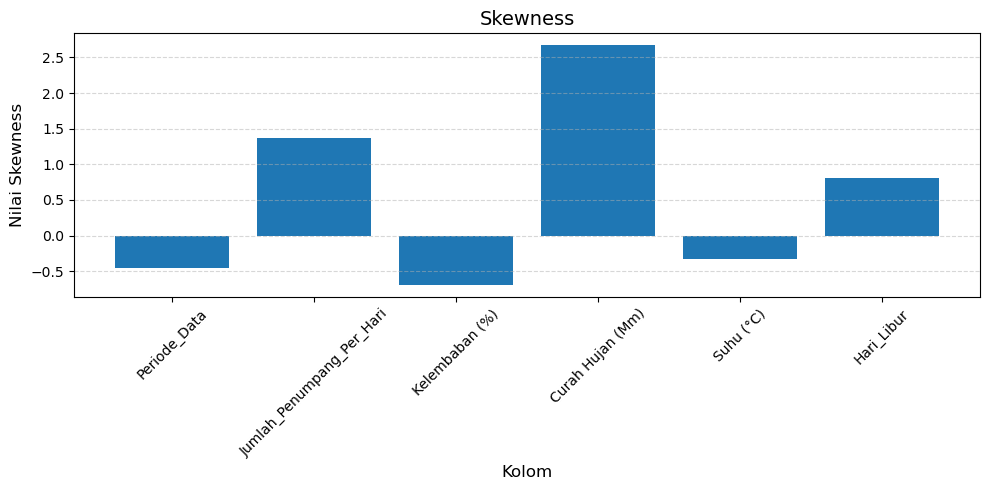

In [852]:
skew = user_data.skew(numeric_only=True)
plt.figure(figsize=(10,5))
plt.bar(skew.index, skew.values)

plt.title("Skewness", fontsize=14)
plt.xlabel("Kolom", fontsize=12)
plt.ylabel("Nilai Skewness", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

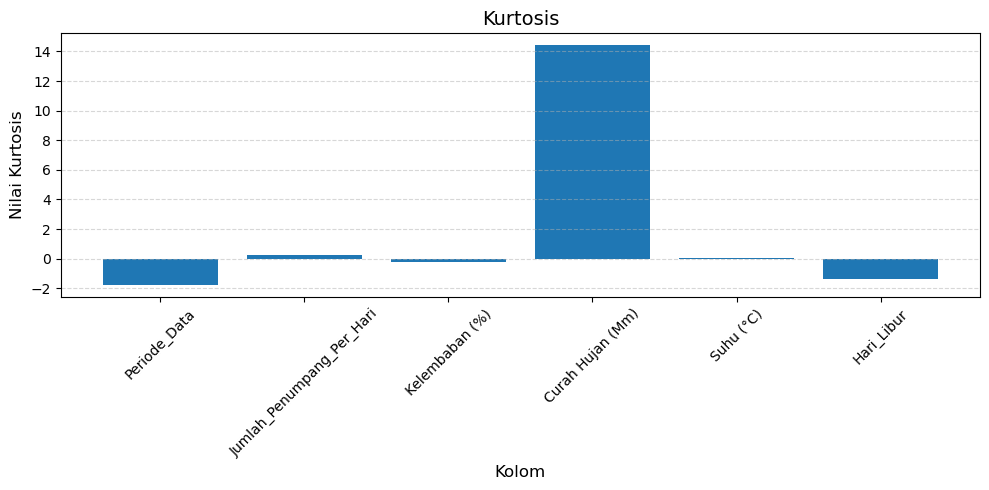

In [853]:
kurt = user_data.kurt(numeric_only=True)
plt.figure(figsize=(10,5))
plt.bar(kurt.index, kurt.values)

plt.title("Kurtosis", fontsize=14)
plt.xlabel("Kolom", fontsize=12)
plt.ylabel("Nilai Kurtosis", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### Plot histogram untuk semua kolom numerik

In [854]:
user_data_for_hist = user_data.select_dtypes(exclude=['bool'])
user_data_for_hist = user_data.drop(['Periode_Data'], axis=1) # hapus kolom Periode_Data karena tidak penting

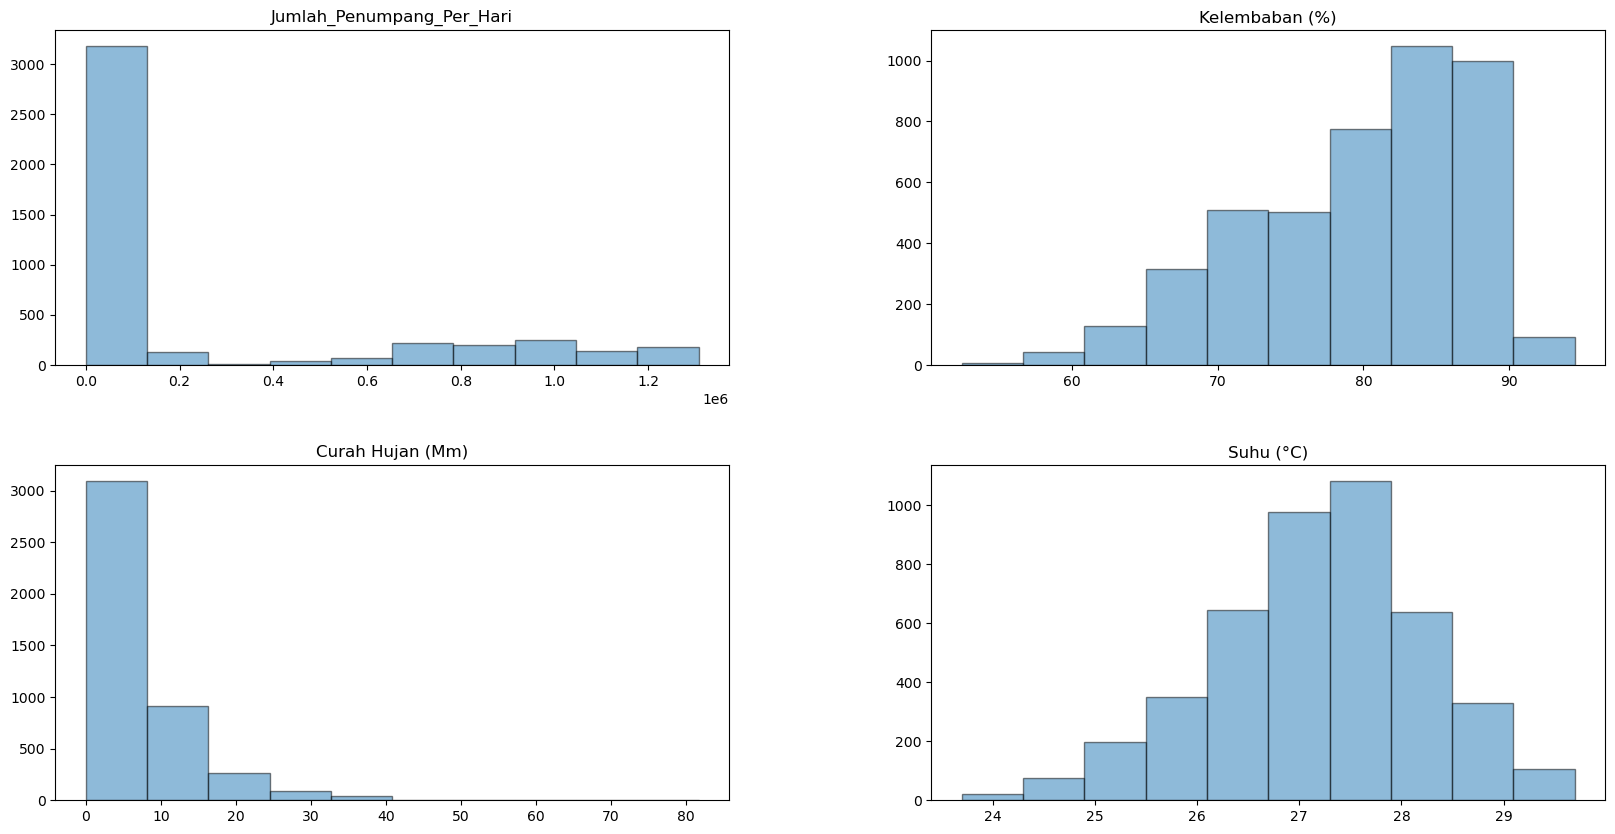

In [855]:
user_data_for_hist.hist(figsize=(20,10), alpha = 0.5, edgecolor='black',grid=False);


#### Tampilkan box plot untuk jumlah penumpang

In [856]:
user_data['Jumlah_Penumpang_Per_Hari'].describe()

count    4.413000e+03
mean     2.511796e+05
std      4.020775e+05
min      0.000000e+00
25%      3.283000e+03
50%      3.283600e+04
75%      2.702810e+05
max      1.307318e+06
Name: Jumlah_Penumpang_Per_Hari, dtype: float64

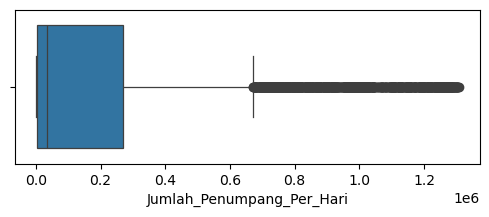

In [857]:
plt.figure(figsize=(6,2))
sns.boxplot(x=user_data['Jumlah_Penumpang_Per_Hari'],linewidth=0.9);

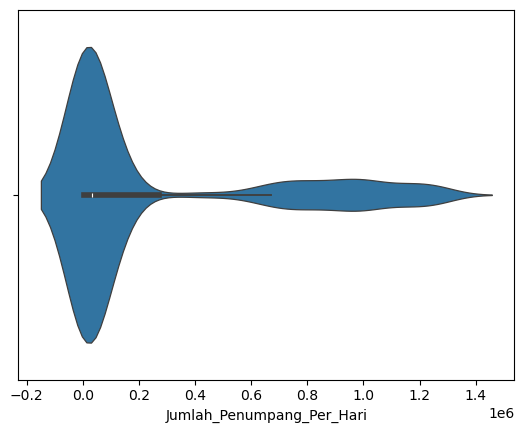

In [858]:
sns.violinplot(x=user_data['Jumlah_Penumpang_Per_Hari'], linewidth=0.9);

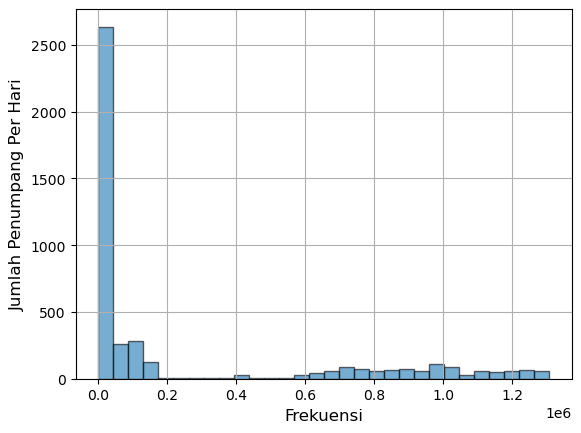

In [859]:
# user_data.Jumlah_Penumpang_Per_Hari.hist(alpha = 0.5, edgecolor='black',grid=False);
user_data.Jumlah_Penumpang_Per_Hari.hist(bins=30, alpha=0.6, edgecolor='black');
plt.xlabel("Frekuensi", fontsize=12);
plt.ylabel("Jumlah Penumpang Per Hari", fontsize=12);


1. Analisis perbandingan Jumlah Penumpang KRL saat cuaca hujan dan cuaca cerah

In [860]:
# Contoh Data Penumpang KRL dengan Kolom Cuaca_Hujan dan Jumlah_Penumpang
user_data['Cuaca_Hujan'] = (
    (user_data['Curah Hujan (Mm)'] > 5) &
    (user_data['Kelembaban (%)'] > 80)
)
krl = user_data[user_data['Jenis_Moda'] == 'krl'].copy()
krl = krl[['Tanggal', 'Jenis_Moda', 'Cuaca_Hujan', 'Jumlah_Penumpang_Per_Hari']]
krl.head(10)

,Tanggal,Jenis_Moda,Cuaca_Hujan,Jumlah_Penumpang_Per_Hari
1218,2023-01-01,krl,True,568322.0
1219,2023-01-02,krl,True,747277.0
1220,2023-01-03,krl,True,675999.0
1221,2023-01-04,krl,True,615017.0
1222,2023-01-05,krl,False,811343.0
1223,2023-01-06,krl,False,812263.0
1224,2023-01-07,krl,False,675174.0
1225,2023-01-08,krl,False,586670.0
1226,2023-01-09,krl,False,807251.0
1227,2023-01-10,krl,False,758716.0


In [861]:
# Rata-rata Penumpang KRL: Cuaca Hujan vs Cuaca Cerah 
krl_mean = krl.groupby('Cuaca_Hujan')['Jumlah_Penumpang_Per_Hari'].mean()
krl_mean

Cuaca_Hujan
False    820046.223796
True     771860.933333
Name: Jumlah_Penumpang_Per_Hari, dtype: float64

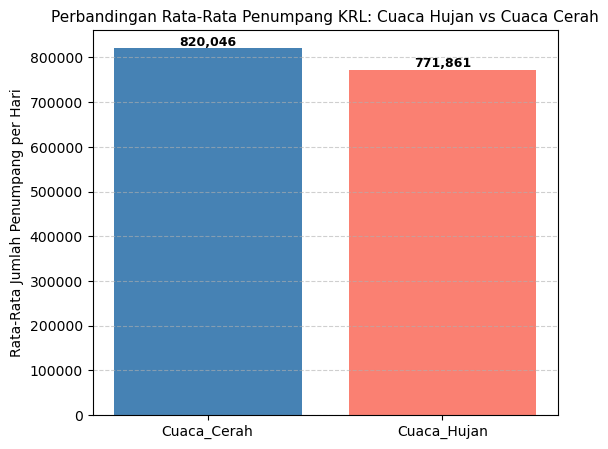

In [862]:
krl_mean = (
    krl.groupby('Cuaca_Hujan')['Jumlah_Penumpang_Per_Hari']
    .mean()
    .reset_index()
)

krl_mean['Kategori'] = krl_mean['Cuaca_Hujan'].map({False: 'Cuaca_Cerah', True: 'Cuaca_Hujan'})
rata_trans = krl_mean.sort_values('Cuaca_Hujan')

plt.figure(figsize=(6, 5))
bars = plt.bar(
    krl_mean['Kategori'],
    krl_mean['Jumlah_Penumpang_Per_Hari'],
    color=['steelblue', 'salmon']
)

plt.title('Perbandingan Rata-Rata Penumpang KRL: Cuaca Hujan vs Cuaca Cerah', fontsize=11)
plt.ylabel('Rata-Rata Jumlah Penumpang per Hari')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
plt.show()

2. Analisis perbandingan Jumlah Penumpang Transjakarta saat Hari libur dan Hari Kerja

In [863]:
transjakarta = user_data[user_data['Jenis_Moda'] == 'transjakarta'].copy()
transjakarta = transjakarta[['Tanggal', 'Hari', 'Hari_Libur', 'Jumlah_Penumpang_Per_Hari']]

# print(" Contoh Data TransJakarta dengan Kolom Hari dan Status Libur")
# print(transjakarta.head(10))
transjakarta[40:90]

,Tanggal,Hari,Hari_Libur,Jumlah_Penumpang_Per_Hari
3113,2023-02-10,Jumat,False,32836.0
3114,2023-02-11,Sabtu,True,32836.0
3115,2023-03-01,Rabu,False,55942.0
3116,2023-03-02,Kamis,False,24204.0
3117,2023-03-03,Jumat,False,251365.0
3118,2023-03-04,Sabtu,True,264137.0
3119,2023-03-05,Minggu,True,230435.0
3120,2023-03-06,Senin,False,414003.0
3121,2023-03-07,Selasa,False,407278.0
3122,2023-03-08,Rabu,False,411878.0


In [864]:
trans = user_data[user_data['Jenis_Moda'] == 'transjakarta'].copy()
rata_trans = trans.groupby('Hari_Libur')['Jumlah_Penumpang_Per_Hari'].mean()

print("Rata-rata Penumpang TransJakarta: Hari Kerja vs Hari Libur ")
print(rata_trans)

Rata-rata Penumpang TransJakarta: Hari Kerja vs Hari Libur 
Hari_Libur
False    1.025439e+06
True     6.509594e+05
Name: Jumlah_Penumpang_Per_Hari, dtype: float64


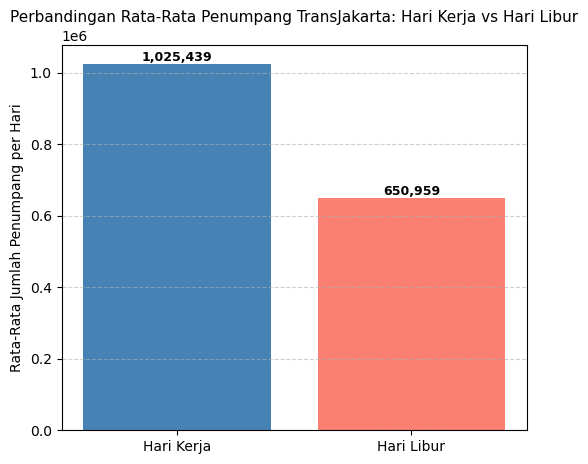

In [865]:
rata_trans = (
    transjakarta.groupby('Hari_Libur')['Jumlah_Penumpang_Per_Hari']
    .mean()
    .reset_index()
)

rata_trans['Kategori'] = rata_trans['Hari_Libur'].map({False: 'Hari Kerja', True: 'Hari Libur'})
rata_trans = rata_trans.sort_values('Hari_Libur')

plt.figure(figsize=(6, 5))
bars = plt.bar(
    rata_trans['Kategori'],
    rata_trans['Jumlah_Penumpang_Per_Hari'],
    color=['steelblue', 'salmon']
)

plt.title('Perbandingan Rata-Rata Penumpang TransJakarta: Hari Kerja vs Hari Libur', fontsize=11)
plt.ylabel('Rata-Rata Jumlah Penumpang per Hari')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
plt.show()

3. Tren Bulananan Penumpang Seluruh Moda

In [866]:
user_data['Tanggal'] = pd.to_datetime(user_data['Tanggal'], errors='coerce')
user_data['Bulan'] = user_data['Tanggal'].dt.to_period('M')
user_data.dropna(subset=['Jenis_Moda'], inplace=True)
tren_bulanan = (
    user_data.groupby(['Bulan', 'Jenis_Moda'])['Jumlah_Penumpang_Per_Hari']
    .mean()
    .reset_index()
)
tren_bulanan['Bulan'] = tren_bulanan['Bulan'].astype(str)

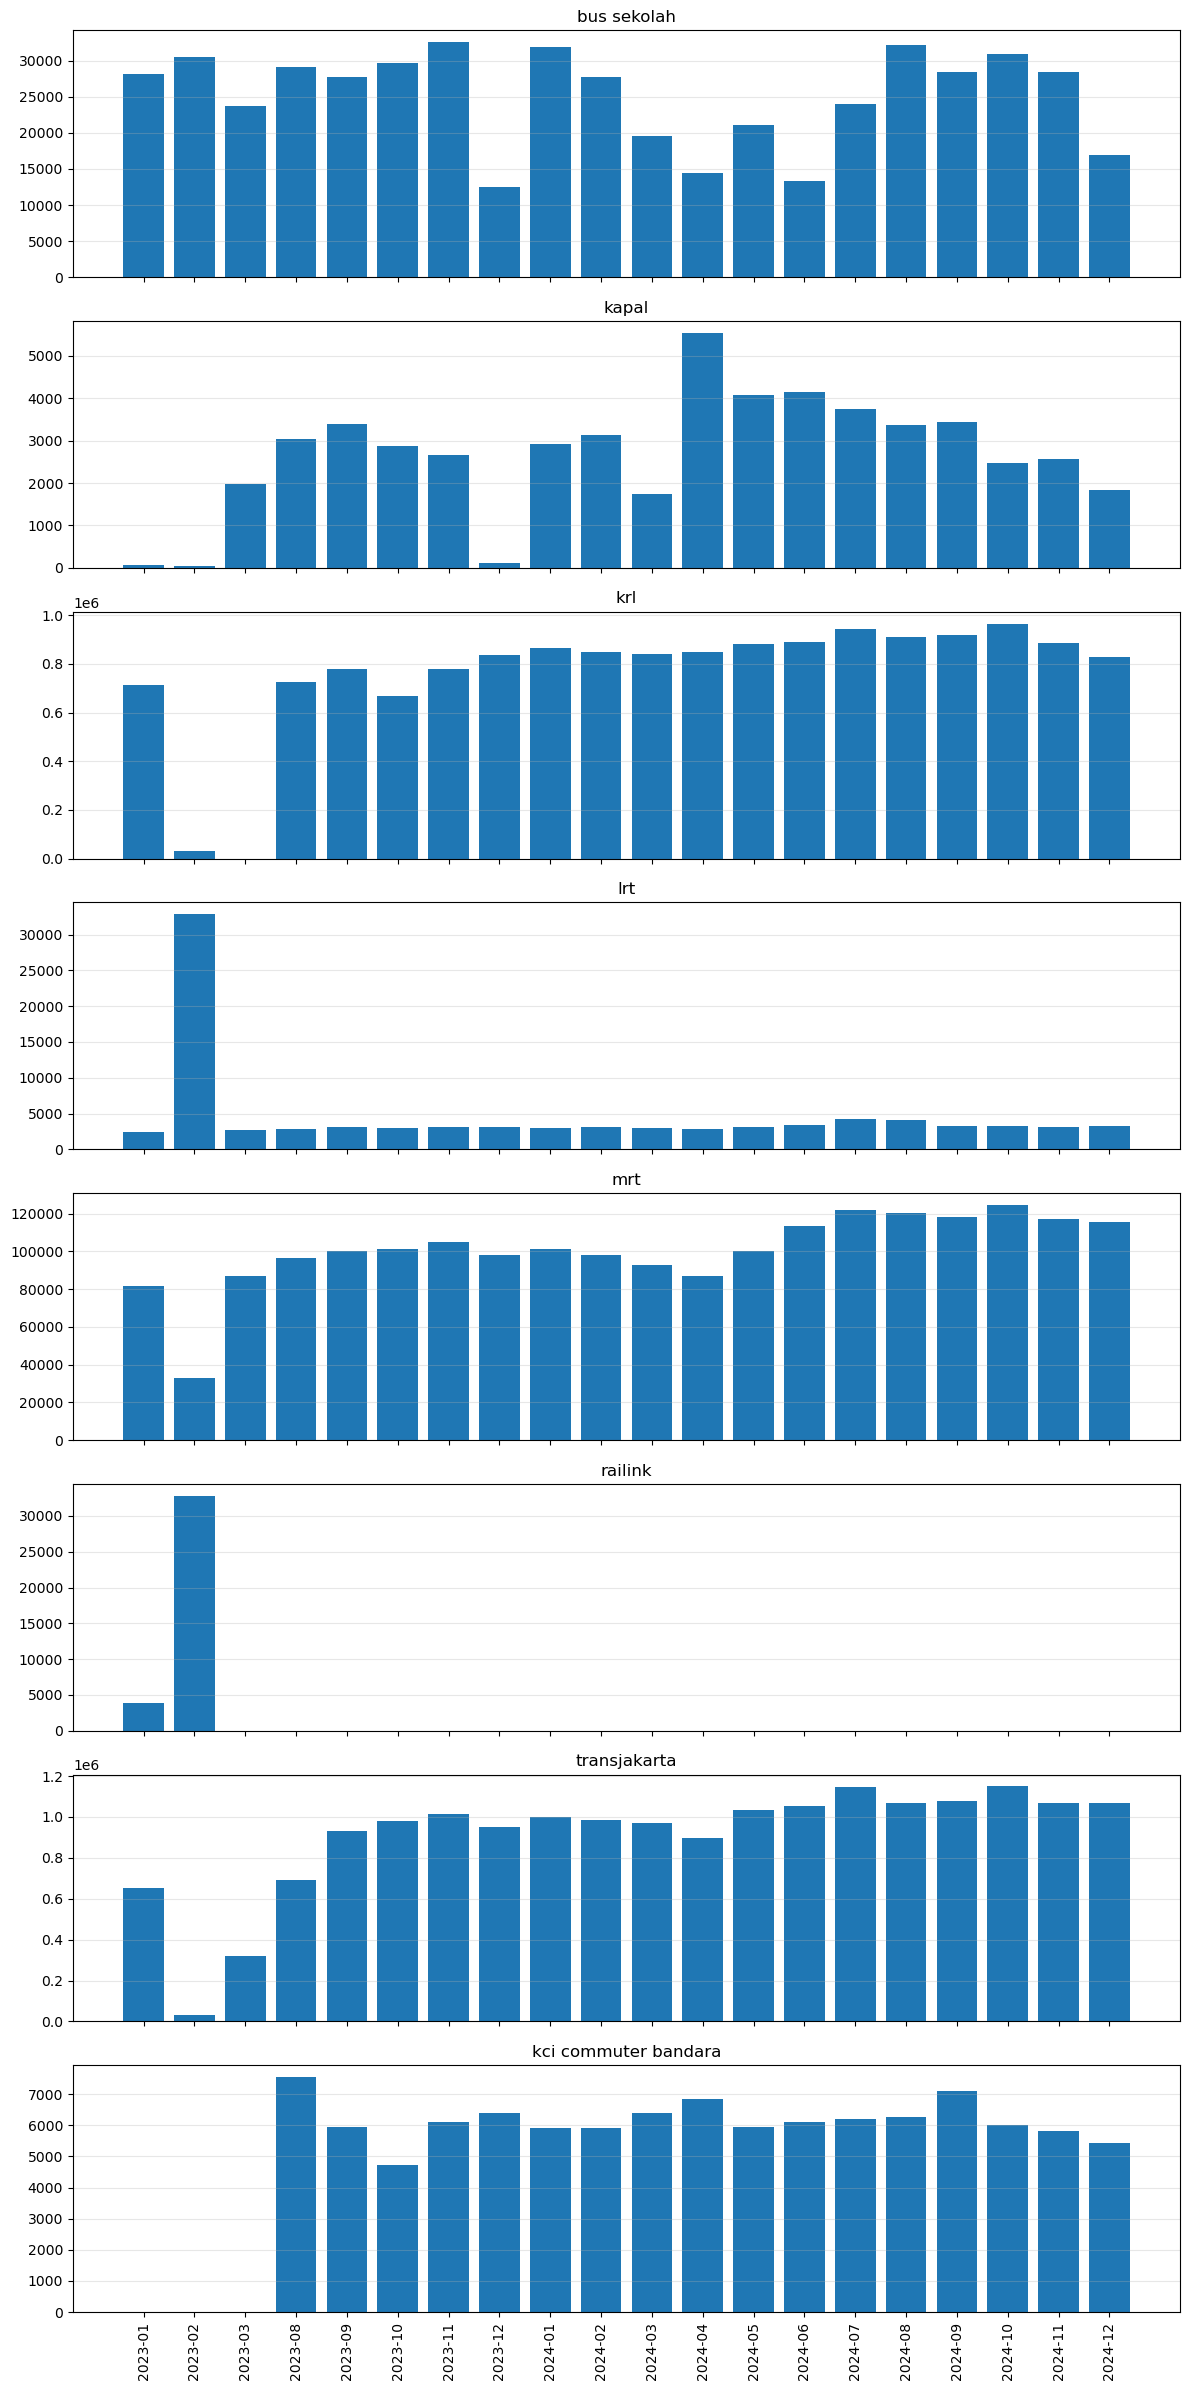

In [867]:
moda_fokus = user_data['Jenis_Moda'].unique()
fig, axs = plt.subplots(len(moda_fokus), 1, figsize=(12, 3 * len(moda_fokus)), sharex=True)

for i, moda in enumerate(moda_fokus):
    subset = tren_bulanan[tren_bulanan['Jenis_Moda'] == moda]
    axs[i].bar(subset['Bulan'], subset['Jumlah_Penumpang_Per_Hari'])
    axs[i].set_title(moda)
    axs[i].grid(axis='y', alpha=0.3)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

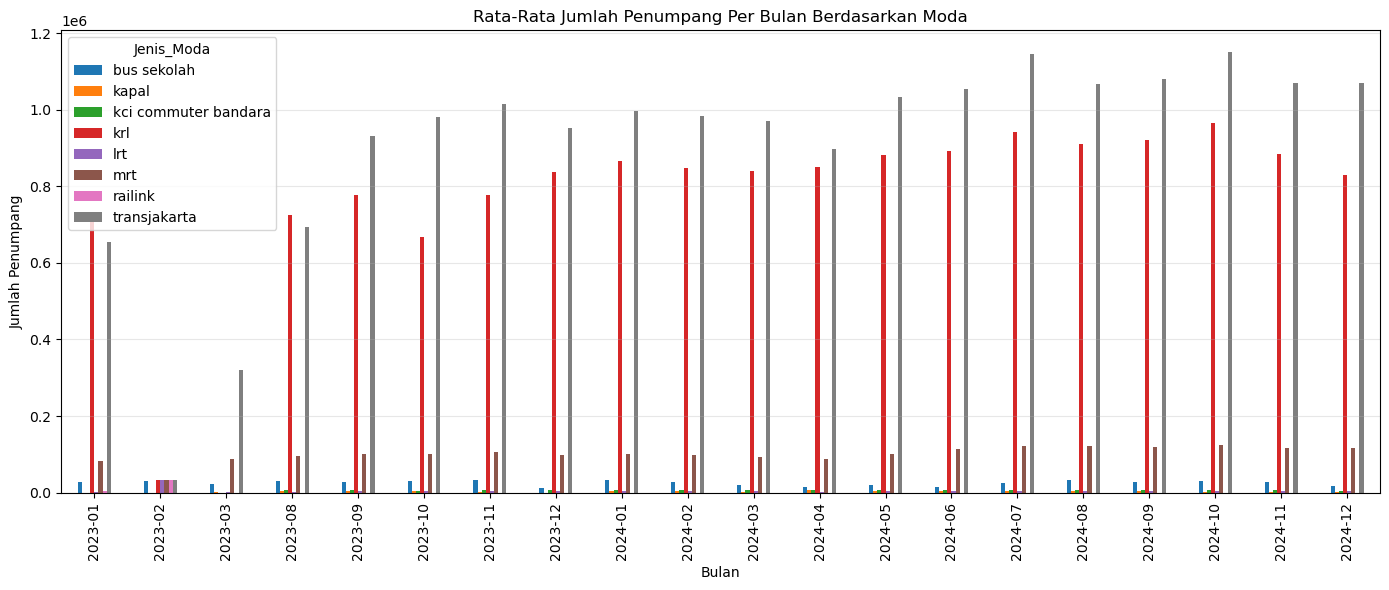

In [868]:
pivot = tren_bulanan.pivot(index='Bulan', columns='Jenis_Moda', values='Jumlah_Penumpang_Per_Hari')

pivot.plot(kind='bar', figsize=(14, 6))

plt.title("Rata-Rata Jumlah Penumpang Per Bulan Berdasarkan Moda")
plt.ylabel("Jumlah Penumpang")
plt.xlabel("Bulan")
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

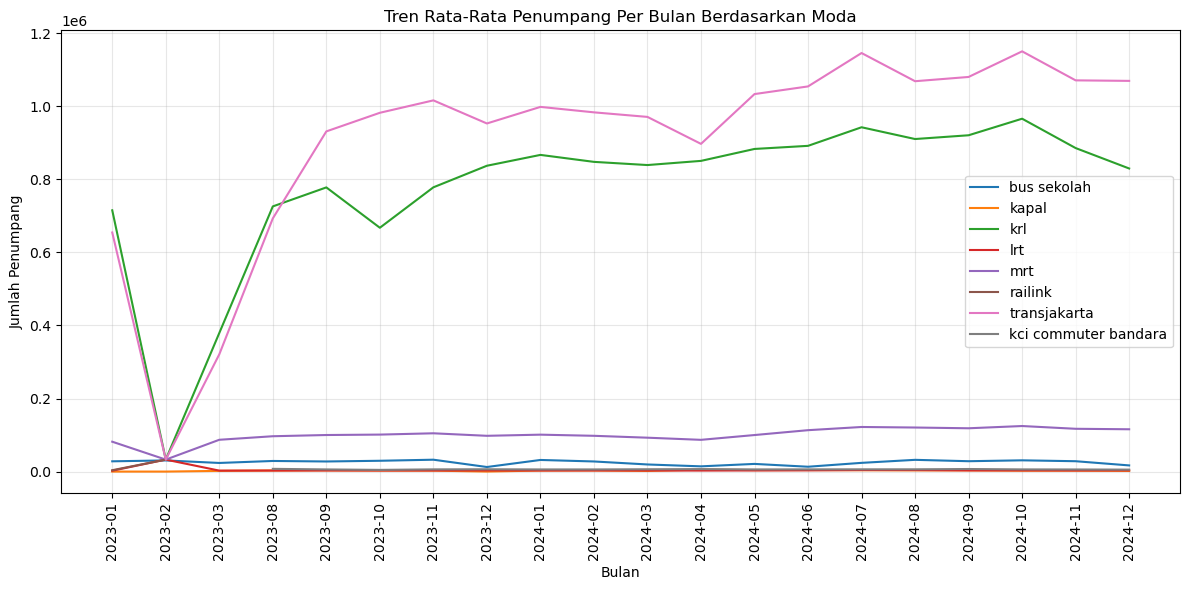

In [869]:
plt.figure(figsize=(12, 6))

for moda in moda_fokus:
    subset = tren_bulanan[tren_bulanan['Jenis_Moda'] == moda]
    plt.plot(subset['Bulan'], subset['Jumlah_Penumpang_Per_Hari'], label=moda)

plt.title("Tren Rata-Rata Penumpang Per Bulan Berdasarkan Moda")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Penumpang")
plt.xticks(rotation=90)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

4. Proporsi penumpang per moda

In [870]:
data_2023 = user_data[user_data['Tanggal'].dt.year == 2023]
data_2024 = user_data[user_data['Tanggal'].dt.year == 2024]
total_moda_2023 = data_2023.groupby('Jenis_Moda')['Jumlah_Penumpang_Per_Hari'].sum().sort_values(ascending=False)
total_moda_2024 = data_2024.groupby('Jenis_Moda')['Jumlah_Penumpang_Per_Hari'].sum().reindex(total_moda_2023.index).fillna(0)

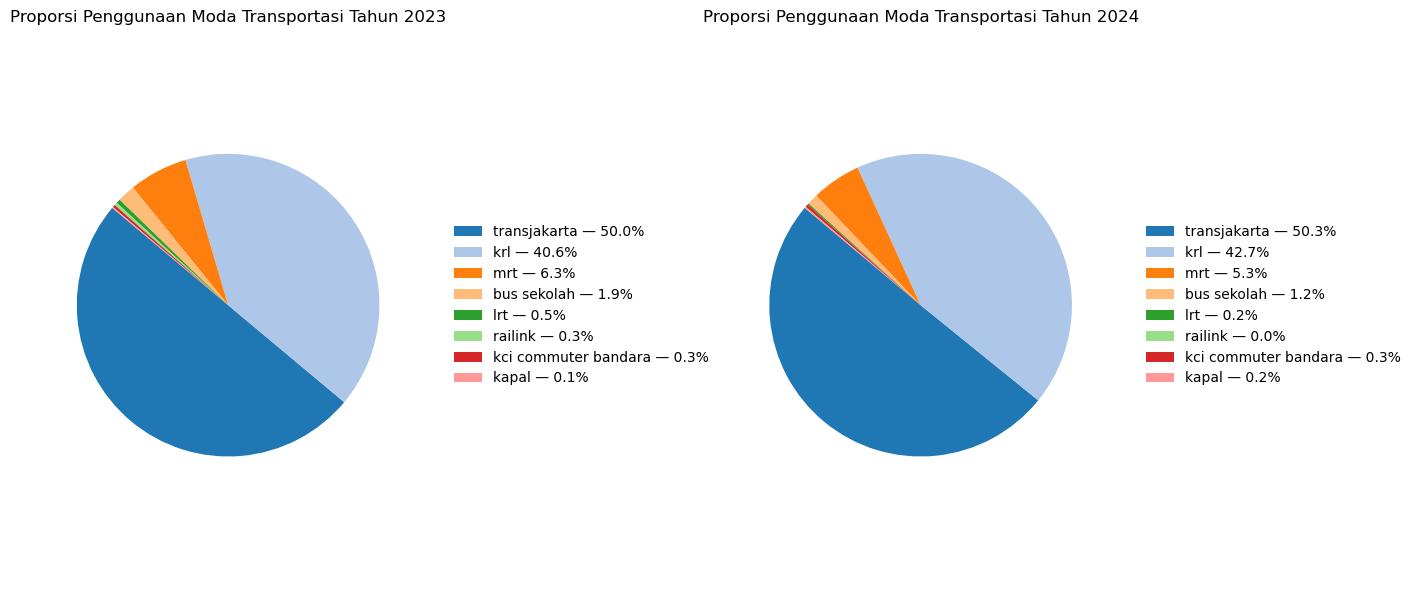

In [871]:
cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(len(total_moda_2023))]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vals1 = total_moda_2023.values
pct1 = 100 * vals1 / vals1.sum()
labels1 = [f"{lab} — {p:.1f}%" for lab, p in zip(total_moda_2023.index, pct1)]

wedges1, _ = axes[0].pie(
    vals1,
    labels=None,
    startangle=140,
    colors=colors
)
axes[0].set_title("Proporsi Penggunaan Moda Transportasi Tahun 2023")
axes[0].axis('equal')
axes[0].legend(wedges1, labels1, loc='center left', bbox_to_anchor=(1.1, 0.5), frameon=False)

vals2 = total_moda_2024.values
pct2 = 100 * vals2 / vals2.sum()
labels2 = [f"{lab} — {p:.1f}%" for lab, p in zip(total_moda_2024.index, pct2)]

wedges2, _ = axes[1].pie(
    vals2,
    labels=None,
    startangle=140,
    colors=colors
)
axes[1].set_title("Proporsi Penggunaan Moda Transportasi Tahun 2024")
axes[1].axis('equal')
axes[1].legend(wedges2, labels2, loc='center left', bbox_to_anchor=(1.1, 0.5), frameon=False)

plt.tight_layout()
plt.show()